# Symplectization

## Particle under the influence of an electric field

The system to work with (explained in detail in the [main document](https://www.overleaf.com/8939674148ymdnppkcnxpr#3514af)) has the following Hamiltonian:
$$
H(q,p,t) = \frac{ \|p\|^2 }{2m} - e\, q \cdot E(t).
$$
from which the Hamiltonian equations can be derived:
$$
\begin{array}{c}
\dot q := \frac{\partial H}{\partial p} = \frac{p}{m}, &
\dot p := -\frac{\partial H}{\partial q} = e \cdot E(t), &
\dot t := \frac{\partial t}{\partial t} = 1
\end{array}
$$

## The proposed modification

The Hamiltonian equations can be preserved even if the Hamiltonian is multiplied by a real-valued function of another variable (i.e., different from $p, q$ and $t$). This yields, inevitably (unless the function is $f(x) = 1 \,\, \forall x$), another Hamiltonian function which must (?) be equal to the original Hamiltonian function for some value of $f$. To put it briefly, if $f: U \overset{ab}{\subseteq} \mathbb{R} \to \mathbb{R}$ then
$$
\tilde{H} := H(q, p, t, r) = f(r)H(p, q, s)
$$
this Hamiltonian's equations are the following:
$$
\begin{array}{c}
\dot q := \frac{\partial \tilde{H}}{\partial p} = \frac{p}{m}, &
\dot p := - \frac{\partial \tilde{H}}{\partial q} = e \cdot E(t), &
\dot t := \frac{\partial t}{\partial t} = 1, &
\dot r := - \frac{\partial \tilde{H}}{\partial t}
\end{array}
$$
as you can see, they are pretty much the same as the original ones except the Hamiltonian has changed and now there are four different equations and the configuration space, in turn, is now an open subset of $\mathbb{R}^4$.

In consequence, we are now working in an even-dimensional space whose 2-form is the sum of two 2-forms: one relating to $p$ and $q$, and another one relating $r$ and $t$. As such, we could, in theory, apply symplectic integrators to the two pair of variables separately and it should not affect the overall result


## Implementation

In [9]:
import math
from typing import Tuple

import pandas as pd
import numpy as np

def f_r(r: np.ndarray) -> np.ndarray:
    return r

def df_dr(r: np.ndarray) -> np.ndarray:
    return 1

def E_s(s: np.ndarray) -> np.ndarray:
    # return np.array([np.sin(s/2), np.cos(s/2)])
    return np.array([np.sin(s/2)])

def dE_ds(s: np.ndarray) -> np.ndarray:
    # return (1/2) * np.array([np.cos(s/2), - np.sin(s/2)])
    return (1/2) * np.array([np.cos(s/2)])

def SI_simplectization(p0: np.ndarray, q0: np.ndarray, r0: np.ndarray, t0: float, t_target: float, f_r: callable, df_dr: callable, E: callable, dE_ds: callable, C: float = 0, m: float = 1, e: float = 1, n_steps: float = 10) -> float:
    pn: np.ndarray = p0
    qn: np.ndarray = q0
    rn: np.ndarray = r0
    tn: float = t0
    df: pd.DataFrame = pd.DataFrame({'pn': [pn], 'qn': [qn], 'tn': [tn], 'rn': [rn]})
    if t_target <= t0:
        raise ValueError(f"Target time ({t_target}) must be greater than the initial time ({t0})")
    h: float = (t_target - t0) / n_steps
    for i in range(n_steps):
        #*Calculate t_{n+1}
        t_np1: float = tn + h

        #*Calculate p_{n+1}
        p_np1: np.ndarray = np.sqrt(2*m *(1/(df_dr(rn)) + e * qn * E(t_np1 + C)))

        #*Calculate q_{n+1}
        q_np1: np.ndarray = qn + h * f_r(rn) * (p_np1 / m)

        #*Calculate r_{n+1}
        r_np1: np.ndarray = rn + h * f_r(rn) * e * qn * dE_ds(t_np1 + C)
        
        #*Update the previous steps
        pn: np.ndarray = p_np1
        qn: np.ndarray = q_np1
        tn: float = t_np1
        rn: np.ndarray = r_np1

        #*Update df
        new_row = pd.DataFrame({'pn': [pn], 'qn': [qn], 'tn': [tn], 'rn': [rn]})
        df = pd.concat([df, new_row], ignore_index=True)

    return df


In [10]:
p0: np.ndarray = np.array([0])
q0: np.ndarray = np.array([1])
r0: np.ndarray = np.array([0])
t0: float = 0
df_result: pd.DataFrame = SI_simplectization(p0, q0, r0, t0, 3, f_r, df_dr, E_s, dE_ds, 1, 1, 30)
df_result

,pn,qn,tn,rn
0,[0],[1],0.0,[0]
1,[6.189602922979985],[1.0],0.3,[0.0]
2,[6.711286423180832],[1.0],0.6,[0.0]
3,[7.127757732089554],[1.0],0.9,[0.0]
4,[7.447982384759387],[1.0],1.2,[0.0]
5,[7.677178984583802],[1.0],1.5,[0.0]
6,[7.818374754340419],[1.0],1.8,[0.0]
7,[7.8731839716445995],[1.0],2.1,[0.0]
8,[7.842186469802163],[1.0],2.4,[0.0]
9,[7.72505742234438],[1.0],2.7,[0.0]


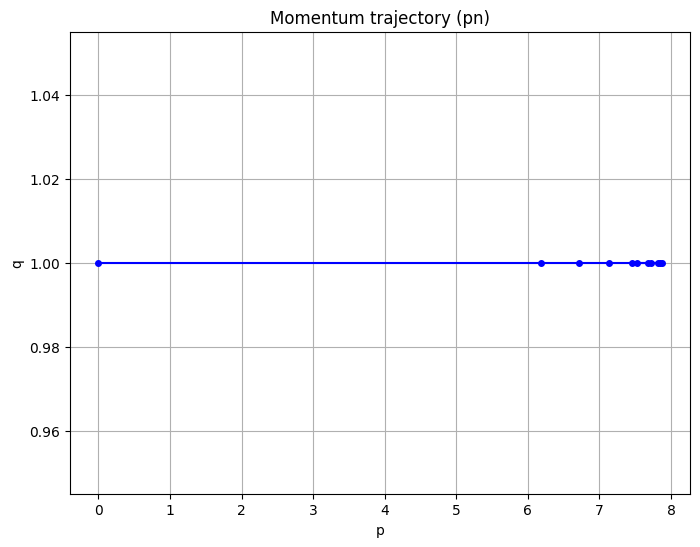

In [11]:
from matplotlib import pyplot as plt

# Extract x and y coordinates from pn column
x_coords = [p[0] for p in df_result['pn']]
y_coords = [q[0] for q in df_result['qn']]

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x_coords, y_coords, 'bo-', markersize=4)
plt.xlabel('p')
plt.ylabel('q')
plt.title('Momentum trajectory (pn)')
plt.grid(True)
plt.show()

In [3]:
import numpy as np

class SymplecticIntegrator1D:
    """
    Simple 1D symplectic integrator (Störmer–Verlet / leapfrog)
    for separable Hamiltonians H(p, q) = T(p) + V(q).
    """

    def __init__(self, dTdp, dVdq):
        """
        Parameters
        ----------
        dTdp : callable
            Function dT/dp(p) -> float
        dVdq : callable
            Function dV/dq(q) -> float
        """
        self.dTdp = dTdp
        self.dVdq = dVdq

    def step(self, p, q, dt):
        """
        Perform one symplectic time step using leapfrog:

            p_{n+1/2} = p_n - (dt/2) * dV/dq(q_n)
            q_{n+1}   = q_n + dt * dT/dp(p_{n+1/2})
            p_{n+1}   = p_{n+1/2} - (dt/2) * dV/dq(q_{n+1})

        Parameters
        ----------
        p, q : float
            Current momentum and position.
        dt : float
            Time step.

        Returns
        -------
        p_new, q_new : float
            Updated momentum and position.
        """
        # Half-step momentum
        p_half = p - 0.5 * dt * self.dVdq(q)
        # Full-step position
        q_new = q + dt * self.dTdp(p_half)
        # Second half-step momentum
        p_new = p_half - 0.5 * dt * self.dVdq(q_new)
        return p_new, q_new

    def integrate(self, p0, q0, dt, n_steps):
        """
        Integrate for n_steps starting from (p0, q0).

        Returns
        -------
        t : np.ndarray
            Times of each step (length n_steps+1).
        qs : np.ndarray
            Positions q at each step.
        ps : np.ndarray
            Momenta p at each step.
        """
        t = np.linspace(0.0, dt * n_steps, n_steps + 1)
        qs = np.empty(n_steps + 1)
        ps = np.empty(n_steps + 1)

        q = q0
        p = p0
        qs[0] = q
        ps[0] = p

        for n in range(n_steps):
            p, q = self.step(p, q, dt)
            ps[n + 1] = p
            qs[n + 1] = q

        return t, qs, ps


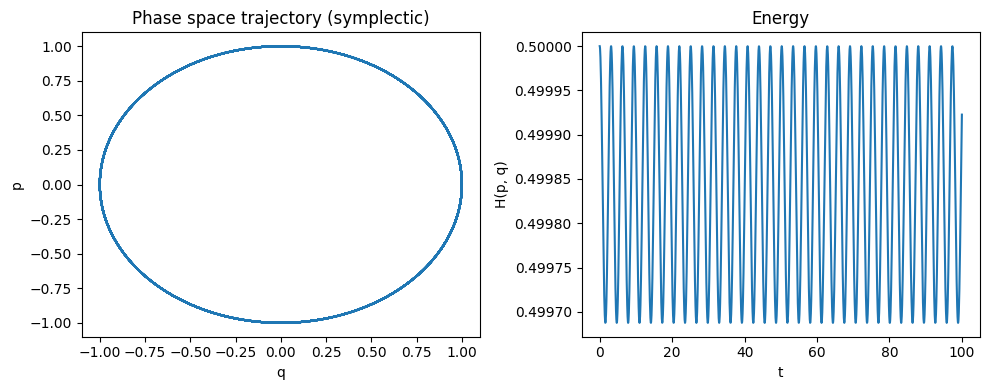

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Physical parameters
m = 1.0
k = 1.0

def dTdp(p):
    return p / m

def dVdq(q):
    return k * q

# Create integrator
integ = SymplecticIntegrator1D(dTdp, dVdq)

# Initial conditions
q0 = 1.0   # initial position
p0 = 0.0   # initial momentum

# Time step and number of steps
dt = 0.05
n_steps = 2000

t, qs, ps = integ.integrate(p0, q0, dt, n_steps)

# Optional: check (approximate) energy conservation
def H(p, q):
    return 0.5 * p**2 / m + 0.5 * k * q**2

Hs = H(ps, qs)

# Plot phase portrait and energy
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

axs[0].plot(qs, ps)
axs[0].set_xlabel("q")
axs[0].set_ylabel("p")
axs[0].set_title("Phase space trajectory (symplectic)")

axs[1].plot(t, Hs)
axs[1].set_xlabel("t")
axs[1].set_ylabel("H(p, q)")
axs[1].set_title("Energy")

plt.tight_layout()
plt.show()
